In [1293]:
# Add any additional libraries or submodules below

# Data libraries
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn modules
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, TargetEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [1294]:
df = pd.read_csv("unicef_malawi.csv")
df.head()

,HH1,HH2,LN,FS4,CB3,CB4,CB5A,CB5B,CB7,CB11,...,HC19,TN1,WS1,WS3,WS4,WS7,WS11,WS14,WS15,HW5
0,1.0,2.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,NO,PIPED WATER: PUBLIC TAP / STANDPIPE,ELSEWHERE,5.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,ELSEWHERE,YES,NO
1,1.0,3.0,1.0,1.0,5.0,YES,ECE,NaN,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT,NO,YES
2,1.0,4.0,2.0,2.0,16.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,6.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,YES
3,1.0,8.0,2.0,2.0,13.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO
4,1.0,10.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,8.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO


To avoid any bias/data leakage, best practice is to split the data to triaing/test before any EDA / Feature Engineering.

However, in order to be able to split the data, all missing data needs to be dealt with. At times .``dropna()`` (remove missing data) can be applied for simplicity, provided we don't lose too much information.

In order to understand run df.info() to understand the structure of the data, missing data, data types etc

In [1295]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13162 entries, 0 to 13161
Data columns (total 87 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   HH1         13162 non-null  float64
 1   HH2         13162 non-null  float64
 2   LN          13162 non-null  float64
 3   FS4         13162 non-null  float64
 4   CB3         13059 non-null  float64
 5   CB4         13059 non-null  object 
 6   CB5A        12203 non-null  object 
 7   CB5B        11575 non-null  object 
 8   CB7         12203 non-null  object 
 9   CB11        13059 non-null  object 
 10  CL3         4159 non-null   float64
 11  CL13        11092 non-null  object 
 12  FCD2A       11264 non-null  object 
 13  FCD2B       11264 non-null  object 
 14  FCD2C       11264 non-null  object 
 15  FCD2D       11264 non-null  object 
 16  FCD2E       11264 non-null  object 
 17  FCD2F       11264 non-null  object 
 18  FCD2G       11264 non-null  object 
 19  FCD2H       11264 non-nul

### 1. Tidy up NaNs

1.1 Observation: 

some columns have significant amount of data missing (CL3 (Child Labour)/FCD5(physical punishment)/HW5 (Handwashing)). If these were insignificant, could be just dropped. 

Kind/gentle/loving physical touch (hugging etc (oxitocin), Maria Rojas Estape's book on oxitocin for example) and playfull time have a great impact on early development of the brain (see also chimpanzee study on baby chimpanzees deprived of food vs deprived of physical touch / other monkeys raised with only presense of an artificial, wired mother-like creature developed significant psychological issues, were less likely to engage with new challenges, very fearful etc [see this: _Together, these studies produced groundbreaking empirical evidence for the primacy of the parent-child attachment relationship and the importance of maternal touch in infant development._ https://www.psychologicalscience.org/publications/observer/obsonline/harlows-classic-studies-revealed-the-importance-of-maternal-contact.html#:~:text=In%20the%20first%2C%20the%20wire,maternal%20touch%20in%20infant%20development.] /  children born during war times etc). Having this in mind, intuitively child labour and physical punishment columns (so forms of potentially depriving a child of either playful time, or indication of potential lack of loving touch) likely were going to be the ones we want to investigate/keep.

Handwashing metric, although not intuitive, can potentially translate to mental health as well (thinking dirt -> inflammation -> long-term alert state of the body -> constant fight-or-flight mode -> depression). Similarly, the gut's microbiome could be affected by this, which has been shown to have direct connection with mental health as well.

`Conclusion:` we likely want to keep these columns

1.2 Let's explore the pattern of missing data (how many in total vs. how many rows are affected)

In [1296]:
print(f"Total NaNs: {df.isnull().sum().sum()}")
print(f"Rows with any NaN: {df.isnull().any(axis=1).sum()}")
print(f"Total NO \"RESPONSE\": {(df == "NO RESPONSE").sum().sum()}")
print(f"Rows with any \"NO RESPONSE\": {df[df == "NO RESPONSE"].any(axis=1).sum()}")


Total NaNs: 71374
Rows with any NaN: 12458
Total NO "RESPONSE": 1293
Rows with any "NO RESPONSE": 1121


IF there is a row that has all values NA -> remove this row

In [1297]:
df.dropna(how='all') 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13162 entries, 0 to 13161
Data columns (total 87 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   HH1         13162 non-null  float64
 1   HH2         13162 non-null  float64
 2   LN          13162 non-null  float64
 3   FS4         13162 non-null  float64
 4   CB3         13059 non-null  float64
 5   CB4         13059 non-null  object 
 6   CB5A        12203 non-null  object 
 7   CB5B        11575 non-null  object 
 8   CB7         12203 non-null  object 
 9   CB11        13059 non-null  object 
 10  CL3         4159 non-null   float64
 11  CL13        11092 non-null  object 
 12  FCD2A       11264 non-null  object 
 13  FCD2B       11264 non-null  object 
 14  FCD2C       11264 non-null  object 
 15  FCD2D       11264 non-null  object 
 16  FCD2E       11264 non-null  object 
 17  FCD2F       11264 non-null  object 
 18  FCD2G       11264 non-null  object 
 19  FCD2H       11264 non-nul

In [1298]:
print(f"Total NaNs: {df.isnull().sum().sum()}")
print(f"Rows with any NaN: {df.isnull().any(axis=1).sum()}")
print(f"Total NO \"RESPONSE\": {(df == "NO RESPONSE").sum().sum()}")
print(f"Rows with any \"NO RESPONSE\": {df[df == "NO RESPONSE"].any(axis=1).sum()}")


Total NaNs: 71374
Rows with any NaN: 12458
Total NO "RESPONSE": 1293
Rows with any "NO RESPONSE": 1121


12,458 rows out of 13,162 have a NaN value. No rows are `entirely` empty. Using dropna() would remove *95%* of data. Likely better ways of dealing with this!

However, only 103 of the target (FCF26) entries are missing (0.8%). These are dropped now as the number is insignificant and we have to know the outcome for training.

`Conclusion:` First, to avoid doing too much work (introducing bias) before splitting the data, we're globally filling in the missing values with one of the already used term in the dataset — 'NO RESPONSE'.

In [1299]:
df[df.isin(['NO RESPONSE']).any(axis=1)]

,HH1,HH2,LN,FS4,CB3,CB4,CB5A,CB5B,CB7,CB11,...,HC19,TN1,WS1,WS3,WS4,WS7,WS11,WS14,WS15,HW5
2,1.0,4.0,2.0,2.0,16.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,6.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,YES
16,2.0,4.0,2.0,2.0,10.0,YES,PRIMARY,CLASS/YEAR/GRADE 4,YES,NO,...,NO,YES,PIPED WATER: PIPED TO YARD / PLOT,NaN,NaN,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT,NO,NaN
31,3.0,17.0,2.0,2.0,8.0,YES,PRIMARY,CLASS/YEAR/GRADE 3,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,20.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,ELSEWHERE,NO,NO
39,4.0,5.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,YES,DUG WELL: PROTECTED WELL,ELSEWHERE,20.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NaN
67,6.0,14.0,2.0,2.0,7.0,YES,PRIMARY,CLASS/YEAR/GRADE 1,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,25.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13026,1101.0,4.0,1.0,1.0,14.0,YES,PRIMARY,CLASS/YEAR/GRADE 5,YES,NO RESPONSE,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,90.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NO
13100,1107.0,4.0,2.0,2.0,5.0,YES,ECE,NaN,YES,NO,...,YES,YES,PIPED WATER: PUBLIC TAP / STANDPIPE,ELSEWHERE,10.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NaN
13124,1109.0,1.0,1.0,1.0,10.0,YES,PRIMARY,CLASS/YEAR/GRADE 4,YES,NO,...,NO,NO,TUBE WELL / BOREHOLE,ELSEWHERE,150.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NaN
13127,1109.0,7.0,2.0,2.0,5.0,YES,ECE,NaN,YES,NO,...,NO,NO,DUG WELL: UNPROTECTED WELL,NO RESPONSE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,YES


In [1300]:
df = df.fillna('NO RESPONSE')

Confirming no data is missing now and the df size reduced to 13059:

In [1301]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13162 entries, 0 to 13161
Data columns (total 87 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   HH1         13162 non-null  float64
 1   HH2         13162 non-null  float64
 2   LN          13162 non-null  float64
 3   FS4         13162 non-null  float64
 4   CB3         13162 non-null  object 
 5   CB4         13162 non-null  object 
 6   CB5A        13162 non-null  object 
 7   CB5B        13162 non-null  object 
 8   CB7         13162 non-null  object 
 9   CB11        13162 non-null  object 
 10  CL3         13162 non-null  object 
 11  CL13        13162 non-null  object 
 12  FCD2A       13162 non-null  object 
 13  FCD2B       13162 non-null  object 
 14  FCD2C       13162 non-null  object 
 15  FCD2D       13162 non-null  object 
 16  FCD2E       13162 non-null  object 
 17  FCD2F       13162 non-null  object 
 18  FCD2G       13162 non-null  object 
 19  FCD2H       13162 non-nul

### 2. Now that we've removed missing values, let's split the data into training and test sets. Column FCF26 is our target (y)

we're using the common 80/20 split for trainig/test, respectively

In [1302]:
X = df.drop(columns=['FCF26']) 
y = df['FCF26']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=8, ## fixing the state for reproducibility
    stratify=y      ## to guarantee balanced split of data
)

#saving as separate dfs
df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

### 3. Now, let's clean up properly the missing data

Start with removing missing values in the target column. There are only 103 (0.8%) missing values in the entire dataset. Besides, we can't train the model without the label.

All further decisions will be made solely on investigating the structures in the training dataset and will be just applied to the test dataset.

In [1303]:
df_train = df_train[df_train['FCF26'] != 'NO RESPONSE']
df_test  = df_test[df_test['FCF26']  != 'NO RESPONSE']

### 3.1 Checking for patterns/correlation in data

<Axes: >

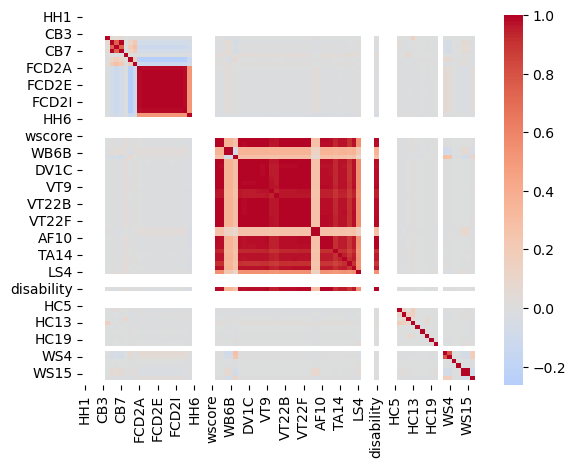

In [1304]:
no_response_matrix = (df_train == 'NO RESPONSE').astype(int)
no_response_corr = no_response_matrix.corr()
sns.heatmap(no_response_corr, cmap='coolwarm', center=0, annot=False)

`Conclusion:` Clear patterns (red squares) in missing responses. This will be investigated in more detail section by section.

#### 3.2 Child Labour

In [1305]:
cols = ['CL2','CL3', 'CL12', 'CL13', 'FCF26']
df_train[df_train['CL3'].isin(['NO RESPONSE'])][cols]

,CL2,CL3,CL12,CL13,FCF26
773,False,NO RESPONSE,True,1.0,A FEW TIMES A YEAR
2464,False,NO RESPONSE,True,4.0,MONTHLY
5113,False,NO RESPONSE,True,0.0,A FEW TIMES A YEAR
10868,False,NO RESPONSE,True,0.0,A FEW TIMES A YEAR
7909,False,NO RESPONSE,True,0.0,NEVER
...,...,...,...,...,...
6910,False,NO RESPONSE,False,NO RESPONSE,NEVER
295,False,NO RESPONSE,True,3.0,MONTHLY
2558,False,NO RESPONSE,True,3.0,A FEW TIMES A YEAR
6331,False,NO RESPONSE,True,30.0,NEVER


In [1306]:
## check how False / True translates to CL2
df_train[df_train['CL3'] == 'NO RESPONSE']['CL2'].value_counts(normalize=True)

CL2
False    1.0
Name: proportion, dtype: float64

_`Conclusion`: wherever CL2 is False (Child Labour = False), there's a missing CL3 value. This means, all CL3 missing values can be set to 0.0 worked hours_

In [1307]:
df_train['CL3'] = df_train['CL3'].replace('NO RESPONSE', 0.0)
df_test['CL3'] = df_test['CL3'].replace('NO RESPONSE', 0.0)

/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_40841/2669409082.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['CL3'] = df_train['CL3'].replace('NO RESPONSE', 0.0)
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_40841/2669409082.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['CL3'] = df_test['CL3'].replace('NO RESPONSE', 0.0)


In [1308]:
df_train[df_train['CL13'] == 'NO RESPONSE']['CL12'].value_counts(normalize=True)

CL12
False    0.998724
True     0.001276
Name: proportion, dtype: float64

_99.8% of data for CL13 and CL12 follow the same rule_

`Conclusion:` _similarly, we make CL13 missing data 0.0_

In [1309]:
df_train['CL13'] = df_train['CL13'].replace('NO RESPONSE', 0.0)
df_test['CL13'] = df_test['CL13'].replace('NO RESPONSE', 0.0)

In [1310]:
# just checking the status of the missing values
print(f"Total NO \"RESPONSE\": {(df_train == "NO RESPONSE").sum().sum()}")
print(f"Rows with any \"NO RESPONSE\": {df_train[df_train == "NO RESPONSE"].any(axis=1).sum()}")

Total NO "RESPONSE": 46369
Rows with any "NO RESPONSE": 8776


Checking key missing-value columns for further investigation/work

In [1311]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

FCD5       3933
HW5        2777
MA3        2376
MA2        2352
WB14       2303
           ... 
MSTATUS       0
CSURV         0
CDEAD         0
CL2           0
FCF26         0
Length: 87, dtype: int64

### 3.3 Physical Punishment

FCD5. _Do you believe that in order to bring up, raise, or educate a child properly, the child needs to be physically punished?_\
checing correlation with other FCD columns

FCD2A-K are different types of physical punishment methods

In [1312]:
fcd_cols = ['FCD5','FCD2A','FCD2B', 'FCD2C',
'FCD2D', 'FCD2E', 'FCD2F', 'FCD2G', 'FCD2H', 'FCD2I', 'FCD2J', 'FCD2K']

df_train[df_train['FCD5'] == 'NO RESPONSE'][fcd_cols + ['FCF26']]

,FCD5,FCD2A,FCD2B,FCD2C,FCD2D,FCD2E,FCD2F,FCD2G,FCD2H,FCD2I,FCD2J,FCD2K,FCF26
773,NO RESPONSE,NO,YES,NO,YES,YES,NO,NO,NO,NO,NO,NO,A FEW TIMES A YEAR
2464,NO RESPONSE,NO,YES,NO,YES,YES,NO,NO,YES,NO,NO,NO,MONTHLY
11506,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,WEEKLY
7909,NO RESPONSE,YES,YES,NO,YES,YES,NO,NO,NO,NO,NO,NO,NEVER
9934,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NEVER
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2777,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NEVER
2558,NO RESPONSE,YES,YES,NO,YES,YES,YES,YES,YES,NO,NO,NO,A FEW TIMES A YEAR
5304,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,A FEW TIMES A YEAR
6331,NO RESPONSE,YES,YES,YES,YES,YES,YES,YES,YES,YES,YES,NO,NEVER


<Axes: >

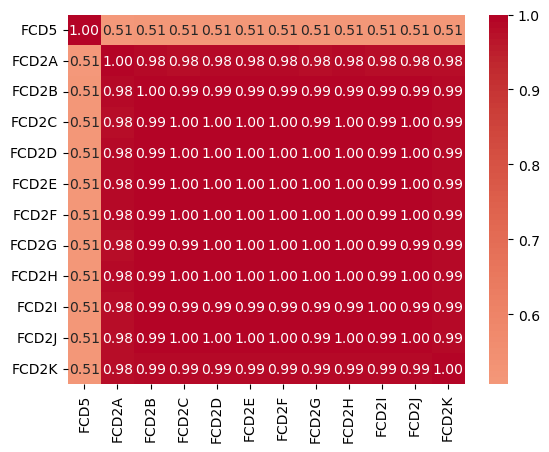

In [1313]:
fcd_no_resp = (df_train[fcd_cols] == 'NO RESPONSE').astype(int)
sns.heatmap(fcd_no_resp.corr(), cmap='coolwarm', center=0, annot=True, fmt='.2f')

_`Conclusion`: If there is missing data for one Physical punishment type (FCD2) column, it is missing in almost all the other FCD2X ones -> it looks like an intentional skip, but we can't quite tell if it's missed because a person doesn't want to disclose what kind of punishment they use OR they don't agree with punishment. 

`First step:` if FCD2 columns are ALL "NO", make FCD5 "NO RESPONSE" a "NO" too. \
If there's any "YES" make it a "YES"._

In [1314]:
fcd2_cols = ['FCD2A','FCD2B', 'FCD2C',
'FCD2D', 'FCD2E', 'FCD2F', 'FCD2G', 'FCD2H', 'FCD2I', 'FCD2J', 'FCD2K']

for df_ in [df_train, df_test]:
    mask = df_['FCD5'].isin(['NO RESPONSE', 'DK / NO OPINION'])
    
    any_yes = df_.loc[mask, fcd2_cols].isin(['YES']).any(axis=1)
    df_.loc[mask & any_yes, 'FCD5'] = 'YES'
    
    all_no = (df_.loc[mask, fcd2_cols] == 'NO').all(axis=1)
    df_.loc[mask & all_no, 'FCD5'] = 'NO'

In [1315]:
df_train['FCD5'].value_counts()

FCD5
NO             5440
YES            3544
NO RESPONSE    1444
Name: count, dtype: int64

In [1316]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

HW5        2777
MA3        2376
MA2        2352
WB14       2303
FCD2A      1479
           ... 
MSTATUS       0
CSURV         0
CDEAD         0
CL2           0
FCF26         0
Length: 87, dtype: int64

### 3.4 Marriage / Partner columns

MSTATUS - current status (formely married / never married / currently married)

MA2. How old is your (husband/partner)?
Probe: How old was your (husband/partner) on his last birthday?

MA3. Besides yourself, does your (husband/partner) have any other wives or partners or does he live with other women as if married?

In [1317]:
top_NaNs_cols = ['MSTATUS','MA3', 'MA2']
df_train[df_train['MA2'] == 'NO RESPONSE'][top_NaNs_cols + ['FCF26']]

,MSTATUS,MA3,MA2,FCF26
11506,Never married/in union,NO RESPONSE,NO RESPONSE,WEEKLY
7909,Formerly married/in union,NO RESPONSE,NO RESPONSE,NEVER
9934,Formerly married/in union,NO RESPONSE,NO RESPONSE,NEVER
12931,Formerly married/in union,NO RESPONSE,NO RESPONSE,WEEKLY
10140,Formerly married/in union,NO RESPONSE,NO RESPONSE,NEVER
...,...,...,...,...
8465,Formerly married/in union,NO RESPONSE,NO RESPONSE,NEVER
10276,Formerly married/in union,NO RESPONSE,NO RESPONSE,MONTHLY
8734,Formerly married/in union,NO RESPONSE,NO RESPONSE,A FEW TIMES A YEAR
8307,Formerly married/in union,NO RESPONSE,NO RESPONSE,A FEW TIMES A YEAR


In [1318]:
print(df_train['MA2'].value_counts(normalize=True))
print(df_train['MA3'].value_counts(normalize=True))

MA2
NO RESPONSE    0.225547
40.0           0.040084
35.0           0.039317
45.0           0.034522
37.0           0.032892
                 ...   
85.0           0.000096
13.0           0.000096
12.0           0.000096
11.0           0.000096
16.0           0.000096
Name: proportion, Length: 70, dtype: float64
MA3
NO             0.656118
NO RESPONSE    0.227848
YES            0.116034
Name: proportion, dtype: float64


About 23% of MA2 and MA3 data missing

In [1319]:
df_train[df_train['MA2'] == 'NO RESPONSE']['MSTATUS'].value_counts(normalize=True)

MSTATUS
Formerly married/in union     0.851616
Never married/in union        0.089286
Currently married/in union    0.059099
Name: proportion, dtype: float64

In [1320]:
df_train[df_train['MA3'] == 'NO RESPONSE']['MSTATUS'].value_counts(normalize=True)

MSTATUS
Formerly married/in union     0.843013
Never married/in union        0.088384
Currently married/in union    0.068603
Name: proportion, dtype: float64

`Conclusion`: strong correlation between missing answers and 'Formely married'.
- If currently married -> pick the most frequent vlaue
- some 'DK' entries -> most frequent
- one numerical entry in MSTATUS -> remove
- Otherwise -> MA2 -> `0.0`, MA3 -> `'NOT MARRIED'`

In [1321]:
imputer = SimpleImputer(strategy='most_frequent', missing_values='NO RESPONSE')

married_mask_train = df_train['MSTATUS'] == 'Currently married/in union'
married_mask_test = df_test['MSTATUS'] == 'Currently married/in union'

df_train.loc[married_mask_train, ['MA2', 'MA3']] = imputer.fit_transform(
    df_train.loc[married_mask_train, ['MA2', 'MA3']]
)
df_test.loc[married_mask_test, ['MA2', 'MA3']] = imputer.transform(
    df_test.loc[married_mask_test, ['MA2', 'MA3']]
)

In [1322]:
df_train.loc[df_train['MA2'] == 'NO RESPONSE', 'MA2'] = 0.0
df_train.loc[df_train['MA3'] == 'NO RESPONSE', 'MA3'] = 'NOT MARRIED'
df_test.loc[df_test['MA2'] == 'NO RESPONSE', 'MA2'] = 0.0
df_test.loc[df_test['MA3'] == 'NO RESPONSE', 'MA3'] = 'NOT MARRIED'
df_train = df_train[df_train['MSTATUS'] != '9.0']
df_test  = df_test[df_test['MSTATUS']   != '9.0']

In [1323]:
imputer = SimpleImputer(strategy='most_frequent', missing_values='DK')

df_train[['MA2']] = imputer.fit_transform(df_train[['MA2']])
df_test[['MA2']] = imputer.transform(df_test[['MA2']])

### 3.5 Education columns (WB5, WB6A, WB6B, WB14)

WB5. _Have you ever attended school or any early childhood education programme?_

WB6. _What is the highest level and grade or year of school you have attended?_

In [1324]:
print(df_train['WB5'].value_counts(normalize=True))
print(df_train['WB6A'].value_counts(normalize=True))
print(df_train['WB6B'].value_counts(normalize=True))
print(df_train['WB14'].value_counts(normalize=True))

WB5
YES            0.859403
NO             0.118826
NO RESPONSE    0.021770
Name: proportion, dtype: float64
WB6A
PRIMARY                0.659538
NO RESPONSE            0.140597
LOWER SECONDARY        0.096288
UPPER SECONDARY        0.083821
HIGHER                 0.017838
VOCATIONAL TRAINING    0.001534
ECE                    0.000384
Name: proportion, dtype: float64
WB6B
CLASS/GRADE 8         0.143761
NO RESPONSE           0.140980
CLASS/YEAR/GRADE 4    0.140980
CLASS/YEAR/GRADE 2    0.124676
CLASS/GRADE 7         0.107222
CLASS/YEAR/GRADE 3    0.098974
CLASS/YEAR/GRADE 5    0.096384
CLASS/GRADE 6         0.084588
CLASS/YEAR/GRADE 1    0.062338
DK                    0.000096
Name: proportion, dtype: float64
WB14
ABLE TO READ WHOLE SENTENCE                   0.356382
CANNOT READ AT ALL                            0.339024
NO RESPONSE                                   0.220773
ABLE TO READ ONLY PARTS OF SENTENCE           0.081519
NO SENTENCE IN REQUIRED LANGUAGE / BRAILLE    0.002302
N

In [1325]:
edu_NaN_cols = ['WB14', 'WB5', 'WB6B', 'WB6A']
df_train[df_train['WB14'] == 'NO RESPONSE'][edu_NaN_cols + ['FCF26']]

,WB14,WB5,WB6B,WB6A,FCF26
2464,NO RESPONSE,YES,CLASS/YEAR/GRADE 1,HIGHER,MONTHLY
11506,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,WEEKLY
9934,NO RESPONSE,YES,CLASS/YEAR/GRADE 4,UPPER SECONDARY,NEVER
1377,NO RESPONSE,YES,CLASS/YEAR/GRADE 3,UPPER SECONDARY,NEVER
12665,NO RESPONSE,YES,CLASS/YEAR/GRADE 1,LOWER SECONDARY,DAILY
...,...,...,...,...,...
12800,NO RESPONSE,YES,CLASS/YEAR/GRADE 4,UPPER SECONDARY,NEVER
5578,NO RESPONSE,YES,CLASS/YEAR/GRADE 2,LOWER SECONDARY,A FEW TIMES A YEAR
9431,NO RESPONSE,YES,CLASS/YEAR/GRADE 2,LOWER SECONDARY,A FEW TIMES A YEAR
2777,NO RESPONSE,YES,CLASS/YEAR/GRADE 1,LOWER SECONDARY,NEVER


In [1326]:
print(df_train['WB5'].value_counts(normalize=True))
print(df_train['WB6A'].value_counts(normalize=True))
print(df_train['WB6B'].value_counts(normalize=True))
print(df_train['WB14'].value_counts(normalize=True))

WB5
YES            0.859403
NO             0.118826
NO RESPONSE    0.021770
Name: proportion, dtype: float64
WB6A
PRIMARY                0.659538
NO RESPONSE            0.140597
LOWER SECONDARY        0.096288
UPPER SECONDARY        0.083821
HIGHER                 0.017838
VOCATIONAL TRAINING    0.001534
ECE                    0.000384
Name: proportion, dtype: float64
WB6B
CLASS/GRADE 8         0.143761
NO RESPONSE           0.140980
CLASS/YEAR/GRADE 4    0.140980
CLASS/YEAR/GRADE 2    0.124676
CLASS/GRADE 7         0.107222
CLASS/YEAR/GRADE 3    0.098974
CLASS/YEAR/GRADE 5    0.096384
CLASS/GRADE 6         0.084588
CLASS/YEAR/GRADE 1    0.062338
DK                    0.000096
Name: proportion, dtype: float64
WB14
ABLE TO READ WHOLE SENTENCE                   0.356382
CANNOT READ AT ALL                            0.339024
NO RESPONSE                                   0.220773
ABLE TO READ ONLY PARTS OF SENTENCE           0.081519
NO SENTENCE IN REQUIRED LANGUAGE / BRAILLE    0.002302
N

In [1327]:
df_train[df_train['WB6A'] == 'NO RESPONSE'][edu_NaN_cols].value_counts(normalize=True)

WB14                                        WB5          WB6B         WB6A       
CANNOT READ AT ALL                          NO           NO RESPONSE  NO RESPONSE    0.809004
NO RESPONSE                                 NO RESPONSE  NO RESPONSE  NO RESPONSE    0.154161
ABLE TO READ WHOLE SENTENCE                 NO           NO RESPONSE  NO RESPONSE    0.019100
ABLE TO READ ONLY PARTS OF SENTENCE         NO           NO RESPONSE  NO RESPONSE    0.015007
NO RESPONSE                                 NO           NO RESPONSE  NO RESPONSE    0.001364
ABLE TO READ ONLY PARTS OF SENTENCE         NO RESPONSE  NO RESPONSE  NO RESPONSE    0.000682
NO SENTENCE IN REQUIRED LANGUAGE / BRAILLE  NO           NO RESPONSE  NO RESPONSE    0.000682
Name: proportion, dtype: float64

`Conclusion`: If WB5 is "NO" or NaN, WB6A and WB6B have missing values. Most likely the woman just didn't attend school..? 

WB14 for most of the WB5/6A/6B entries is "CANNOT READ AT ALL" with a few exceptions -> changing WB5 to "NO" and WB6A/B to "NO EDUCATION".

In [1328]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='most_frequent', missing_values='NO RESPONSE')

df_train[['WB6A', 'WB6B', 'WB14']] = imputer.fit_transform(df_train[['WB6A','WB6B', 'WB14']])
df_test[['WB6A','WB6B', 'WB14']] = imputer.transform(df_test[['WB6A','WB6B', 'WB14']])
df_train.loc[df_train['WB5'] == 'NO RESPONSE', 'WB5'] = 'NO'
df_test.loc[df_test['WB5'] == 'NO RESPONSE', 'WB5'] = 'NO'

### 3.6 Water sanitation & handwashing columns

WS1. _What is the main source of drinking water used by members of your household?_

WS3. _Where is that water source located?_

WS4. _How long does it take for members of your household to go there, get water, and come back?_

WS7. _In the last month, has there been any time when your household did not have sufficient quantities of drinking water?_

WS11. _What kind of toilet facility do members of your household usually use?_

WS14. _Where is this toilet facility located?_

WS15. _Do you share this facility with others who are not members of your household?_

HW5. _Do you have any soap or detergent or ash/mud/sand in your house for washing hands?_

In [1329]:
household_cols = ['HW5', 'WS1', 'WS3', 'WS4', 'WS7', 'WS11', 'WS14', 'WS15']
df_train[df_train['WS4'] == 'NO RESPONSE'][household_cols + ['FCF26']]

,HW5,WS1,WS3,WS4,WS7,WS11,WS14,WS15,FCF26
2464,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK,IN OWN DWELLING,NO,MONTHLY
9934,NO RESPONSE,PIPED WATER: PIPED INTO DWELLING,NO RESPONSE,NO RESPONSE,"YES, AT LEAST ONCE",FLUSH / POUR FLUSH: FLUSH TO PIPED SEWER SYSTEM,IN OWN DWELLING,NO,NEVER
11999,NO,PIPED WATER: PUBLIC TAP / STANDPIPE,IN OWN YARD / PLOT,NO RESPONSE,"NO, ALWAYS SUFFICIENT",NO FACILITY / BUSH / FIELD,NO RESPONSE,NO RESPONSE,NEVER
527,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,A FEW TIMES A YEAR
1206,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NEVER
...,...,...,...,...,...,...,...,...,...
2213,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",OTHER,ELSEWHERE,YES,A FEW TIMES A YEAR
12800,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK,IN OWN DWELLING,NO,NEVER
9431,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",PIT LATRINE: VENTILATED IMPROVED PIT LATRINE,IN OWN YARD / PLOT,NO,A FEW TIMES A YEAR
6910,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NEVER


In [1330]:
# checking unique entriesof the columns
df_train.WS4.unique()

array(['30.0', 'NO RESPONSE', '5.0', '15.0', 'DK', '10.0', '60.0', '25.0',
       '8.0', '7.0', '75.0', '45.0', '20.0', '180.0', '120.0', '90.0',
       '2.0', '40.0', '12.0', '1.0', '17.0', '4.0', '3.0', '50.0', '6.0',
       '24.0', '112.0', '9.0', '55.0', '155.0', '35.0', '100.0', '130.0',
       'MEMBERS DO NOT COLLECT', '42.0', '70.0', '14.0', '240.0', '65.0',
       '22.0', '300.0', '18.0', '13.0', '610.0', '153.0', '41.0', '54.0',
       '80.0', '16.0', '36.0', '34.0', '23.0', '52.0', '360.0', '11.0',
       '21.0', '110.0', '214.0', '540.0', '160.0', '304.0', '200.0',
       '900.0', '26.0', '135.0', '28.0', '98.0', '19.0', '31.0', '46.0',
       '390.0', '95.0', '220.0', '66.0', '33.0', '38.0', '49.0', '32.0',
       '27.0', '48.0'], dtype=object)

In [1331]:
df_train[df_train['WS4'] == 'NO RESPONSE']['WS3'].value_counts(normalize=True)

WS3
NO RESPONSE           0.672401
IN OWN YARD / PLOT    0.309677
IN OWN DWELLING       0.017921
Name: proportion, dtype: float64

In [1332]:
df_train['WS4'].value_counts(normalize=True)

WS4
10.0           0.158914
NO RESPONSE    0.133787
30.0           0.131581
20.0           0.107893
5.0            0.091589
                 ...   
41.0           0.000096
153.0          0.000096
610.0          0.000096
112.0          0.000096
48.0           0.000096
Name: proportion, Length: 80, dtype: float64

In [1333]:
df_train[df_train['WS3'] == 'NO RESPONSE']['WS1'].value_counts(normalize=True)

WS1
PIPED WATER: PIPED TO YARD / PLOT                                            0.776749
PIPED WATER: PIPED INTO DWELLING                                             0.186214
TUBE WELL / BOREHOLE                                                         0.023663
DUG WELL: UNPROTECTED WELL                                                   0.003086
PACKAGED WATER: BOTTLED WATER                                                0.002058
DUG WELL: PROTECTED WELL                                                     0.002058
CART WITH SMALL TANK                                                         0.002058
TANKER-TRUCK                                                                 0.001029
PIPED WATER: PUBLIC TAP / STANDPIPE                                          0.001029
PIPED WATER: PIPED TO NEIGHBOUR                                              0.001029
SURFACE WATER (RIVER, DAM, LAKE, POND, STREAM, CANAL, IRRIGATION CHANNEL)    0.001029
Name: proportion, dtype: float64

In [1334]:
df_train[df_train['WS4'] == 'NO RESPONSE']['WS3'].value_counts(normalize=True)

WS3
NO RESPONSE           0.672401
IN OWN YARD / PLOT    0.309677
IN OWN DWELLING       0.017921
Name: proportion, dtype: float64

In [1335]:
df_train[df_train['WS14'] == 'NO RESPONSE']['WS11'].value_counts(normalize=True)

WS11
NO FACILITY / BUSH / FIELD          0.997449
HANGING TOILET / HANGING LATRINE    0.002551
Name: proportion, dtype: float64

In [1336]:
df_train[df_train['WS4'] == 'DK']['WS3'].value_counts(normalize=True)

WS3
ELSEWHERE    1.0
Name: proportion, dtype: float64

`Conclusion`:
- most of missing data in WS3 has answers in WS1 -> Piped to yard/dwelling. 
    - Changing all WS3 NaNs to "IN OWN YARD / PLOT". 

- WS4 NaN for when WS3 "IN OWN YARD / PLOT", so changing to "MEMBERS DO NOT COLLECT" -> then all 'MEMBERS DO NOT COLLECT' (collectively, including the previous MDNC labels) to 0.0
- WS114 99.7% have no toilet where "NO RESPONSE". 
    - changing 'NO RESPONSE' to "NO TOILET"
- small fraction of WS4's existing 'DK' with WS3's 'Elsewhere' set to the most frequent value

In [1337]:
df_train.loc[df_train['WS3'] == 'NO RESPONSE', 'WS3'] = 'IN OWN YARD / PLOT'
df_test.loc[df_test['WS3'] == 'NO RESPONSE', 'WS3'] = 'IN OWN YARD / PLOT'

df_train.loc[df_train['WS4'] == 'NO RESPONSE', 'WS4'] = 'MEMBERS DO NOT COLLECT'
df_test.loc[df_test['WS4'] == 'NO RESPONSE', 'WS4'] = 'MEMBERS DO NOT COLLECT'
df_train.loc[df_train['WS4'] == 'MEMBERS DO NOT COLLECT', 'WS4'] = 0.0
df_test.loc[df_test['WS4'] == 'MEMBERS DO NOT COLLECT', 'WS4'] = 0.0

df_train.loc[df_train['WS14'] == 'NO RESPONSE', 'WS14'] = 'NO TOILET'
df_test.loc[df_test['WS14'] == 'NO RESPONSE', 'WS14'] = 'NO TOILET'

In [1338]:
imputer = SimpleImputer(strategy='most_frequent', missing_values='DK')

df_train[['WS4']] = imputer.fit_transform(df_train[['WS4']])
df_test[['WS4']] = imputer.transform(df_test[['WS4']])

In [1339]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

HW5        2777
FCD2A      1479
FCD2K      1463
FCD2I      1454
FCD2B      1450
           ... 
HH2           0
MA2           0
MA3           0
MSTATUS       0
FCF26         0
Length: 87, dtype: int64

In [1340]:
df_train[df_train['WS15'] == 'NO RESPONSE']['WS14'].value_counts(normalize=True)

WS14
NO TOILET             0.987374
IN OWN YARD / PLOT    0.011364
ELSEWHERE             0.001263
Name: proportion, dtype: float64

`Conclusion`:
Setting all "NO RESPONSE" to "YES" -> if they don't have a toilet, they share it with others, whether it's a bush or something else.

In [1341]:
df_train.loc[df_train.WS15 == 'NO RESPONSE', 'WS15'] = 'YES'
df_test.loc[df_test.WS15 == 'NO RESPONSE', 'WS15'] = 'YES'

In [1342]:
df_train[df_train['HW5'] == 'NO RESPONSE']['WS14'].value_counts(normalize=True)

WS14
IN OWN YARD / PLOT    0.781419
IN OWN DWELLING       0.094707
ELSEWHERE             0.083543
NO TOILET             0.040331
Name: proportion, dtype: float64

In [1343]:
df_train[df_train['HW5'] == 'NO RESPONSE']['WS11'].value_counts(normalize=True)

WS11
PIT LATRINE: PIT LATRINE WITH SLAB                  0.740367
PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT    0.097587
PIT LATRINE: VENTILATED IMPROVED PIT LATRINE        0.054015
FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK            0.052935
NO FACILITY / BUSH / FIELD                          0.040331
OTHER                                               0.006122
FLUSH / POUR FLUSH: FLUSH TO PIPED SEWER SYSTEM     0.003961
FLUSH / POUR FLUSH: FLUSH TO PIT LATRINE            0.001801
HANGING TOILET / HANGING LATRINE                    0.001801
FLUSH / POUR FLUSH: FLUSH TO DK WHERE               0.000360
FLUSH / POUR FLUSH: FLUSH TO OPEN DRAIN             0.000360
COMPOSTING TOILET                                   0.000360
Name: proportion, dtype: float64

In [1344]:
df_train[df_train['HW5'] == 'NO RESPONSE']['WS3'].value_counts(normalize=True)

WS3
ELSEWHERE             0.766295
IN OWN YARD / PLOT    0.230104
IN OWN DWELLING       0.003601
Name: proportion, dtype: float64

In [1345]:
df_train[df_train['HW5'] == 'NO RESPONSE']['WS4'].value_counts(normalize=True)

WS4
0.0      0.232265
10.0     0.151602
30.0     0.117033
20.0     0.098668
5.0      0.085704
15.0     0.081023
60.0     0.064818
45.0     0.016925
25.0     0.016565
40.0     0.015484
2.0      0.012604
120.0    0.011163
3.0      0.011163
8.0      0.009723
6.0      0.009723
50.0     0.009363
4.0      0.007562
12.0     0.006842
7.0      0.006482
35.0     0.005762
1.0      0.005041
90.0     0.003241
13.0     0.001801
80.0     0.001801
100.0    0.001440
14.0     0.001440
70.0     0.001080
55.0     0.001080
19.0     0.000720
21.0     0.000720
9.0      0.000720
65.0     0.000720
200.0    0.000720
160.0    0.000720
180.0    0.000720
18.0     0.000720
300.0    0.000720
240.0    0.000720
540.0    0.000360
22.0     0.000360
32.0     0.000360
49.0     0.000360
98.0     0.000360
135.0    0.000360
16.0     0.000360
24.0     0.000360
214.0    0.000360
11.0     0.000360
36.0     0.000360
610.0    0.000360
153.0    0.000360
900.0    0.000360
17.0     0.000360
Name: proportion, dtype: float64

`Conclusion`:
Most of the HW5 missing answers have latrines in their own yards, but water sources elsewhere, so most likely don't wash their hands. Changing 'NO RESPONSE' to 'NO'

In [1346]:
df_train.loc[df_train.HW5 == 'NO RESPONSE', 'HW5'] = 'NO'
df_test.loc[df_test.HW5 == 'NO RESPONSE', 'HW5'] = 'NO'

### Child Education Columns

CB3. How old is (name)?  

CB4. Has (name) ever attended school or any early childhood education programme?

CB5. What is the highest level and grade or year of school (name) has ever attended?

CB7. At any time during the current school year did (name) attend school or any early childhood education programme?

CB11. Is (name) covered by any health insurance?

In [1347]:
df_train.CB5A.unique()

array(['PRIMARY', 'NO RESPONSE', 'ECE', 'UPPER SECONDARY',
       'LOWER SECONDARY', 'HIGHER'], dtype=object)

In [1348]:
df_train[df_train['CB5A'] == 'NO RESPONSE']['CB3'].value_counts(normalize=True)

CB3
5.0     0.609001
6.0     0.178622
7.0     0.067511
8.0     0.029536
10.0    0.022504
9.0     0.019691
15.0    0.016878
14.0    0.011252
12.0    0.011252
17.0    0.009845
11.0    0.008439
13.0    0.008439
16.0    0.007032
Name: proportion, dtype: float64

likely just not in school age yet!

In [1349]:
df_train[df_train['CB5B'] == 'NO RESPONSE']['CB4'].value_counts(normalize=True)

CB4
NO             0.587065
YES            0.411277
NO RESPONSE    0.001658
Name: proportion, dtype: float64

In [1350]:
df_train[df_train['CB7'] == 'NO RESPONSE']['CB3'].value_counts(normalize=True)

CB3
5.0     0.609859
6.0     0.178873
7.0     0.067606
8.0     0.029577
10.0    0.022535
9.0     0.019718
15.0    0.016901
14.0    0.011268
12.0    0.011268
17.0    0.009859
11.0    0.008451
16.0    0.007042
13.0    0.007042
Name: proportion, dtype: float64

`Conclusion`: most of the missing values are for 5-year-old children. Changing NO RESPONSE to NOT SCHOOL AGE in both CB5A and CB5B

In [1351]:
df_train.loc[df_train.CB5B == 'NO RESPONSE', 'CB5B'] = 'NOT SCHOOL AGE'
df_train.loc[df_train.CB5A == 'NO RESPONSE', 'CB5A'] = 'NOT SCHOOL AGE'
df_train.loc[df_train.CB7 == 'NO RESPONSE', 'CB7'] = 'NOT SCHOOL AGE'

df_test.loc[df_test.CB5B == 'NO RESPONSE', 'CB5B'] = 'NOT SCHOOL AGE'
df_test.loc[df_test.CB5A == 'NO RESPONSE', 'CB5A'] = 'NOT SCHOOL AGE'
df_test.loc[df_test.CB7 == 'NO RESPONSE', 'CB7'] = 'NOT SCHOOL AGE'

### Life satisfaction columns

LS1. I would like to ask you some simple questions on happiness and satisfaction. \
First, taking all things together, would you say you are very happy, somewhat happy, neither happy nor unhappy, somewhat unhappy or very unhappy?

I am now going to show you pictures to help you with your response.

LS2. Show the picture of the ladder.\
Now, look at this ladder with steps numbered from 0 at the bottom to 10 at the top.
Suppose we say that the top of the ladder represents the best possible life for you and the bottom of the ladder represents the worst possible life for you.
On which step of the ladder do you feel you stand at this time?


LS3. Compared to this time last year, would you say that your life has improved, stayed more or less the same, or worsened, overall?

LS4. And in one year from now, do you expect that your life will be better, will be more or less the same, or will be worse, overall?

In [1352]:
df_train[df_train['LS4'] == 'NO RESPONSE'][['LS3','LS1', 'LS2']].value_counts(normalize=True)

LS3                    LS1                        LS2        
NO RESPONSE            NO RESPONSE                NO RESPONSE    0.308424
MORE OR LESS THE SAME  VERY HAPPY                 10             0.038043
IMPROVED               VERY HAPPY                 10             0.035326
MORE OR LESS THE SAME  NEITHER HAPPY NOR UNHAPPY  5              0.028533
                       VERY HAPPY                 0              0.027174
                                                                   ...   
NO RESPONSE            VERY UNHAPPY               NO RESPONSE    0.001359
WORSENED               NEITHER HAPPY NOR UNHAPPY  4              0.001359
                                                  6              0.001359
                                                  8              0.001359
                       VERY UNHAPPY               NO RESPONSE    0.001359
Name: proportion, Length: 132, dtype: float64

In [1353]:
df_train.LS4.value_counts(normalize=True)

LS4
BETTER                   0.621655
MORE OR LESS THE SAME    0.241776
NO RESPONSE              0.070586
WORSE                    0.065983
Name: proportion, dtype: float64

About 30% skipped the whole section altogether (NO RESPONSE in every column). NO RESPONSE accounts for 7% of answers in the columns only.

`Decision:` Filling in based on the most frequent answer in column

In [1354]:
imputer = SimpleImputer(strategy='most_frequent', missing_values='NO RESPONSE')

df_train[['LS1','LS2', 'LS3','LS4']] = imputer.fit_transform(df_train[['LS1','LS2', 'LS3','LS4']])
df_test[['LS1','LS2', 'LS3','LS4']] = imputer.transform(df_test[['LS1','LS2', 'LS3','LS4']])

In [1355]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

FCD2A    1479
FCD2K    1463
FCD2I    1454
FCD2B    1450
FCD2G    1448
         ... 
MA2         0
MA3         0
LS1         0
LS2         0
FCF26       0
Length: 87, dtype: int64

`Decision:` using the "most frequent" strategy for all the remaining "no response", as there aren't that many counts per columns anymore

In [1356]:
no_response = (df_train == 'NO RESPONSE').sum() / len(df_train)
cols_to_impute = (no_response[no_response < 0.05]).index.tolist()

imputer = SimpleImputer(strategy='most_frequent', missing_values='NO RESPONSE')

df_train[cols_to_impute] = imputer.fit_transform(df_train[cols_to_impute])
df_test[cols_to_impute] = imputer.transform(df_test[cols_to_impute])

In [1357]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

FCD2A    1479
FCD2K    1463
FCD2I    1454
FCD2B    1450
FCD2G    1448
         ... 
DV1C        0
DV1B        0
DV1A        0
WB14        0
FCF26       0
Length: 87, dtype: int64

Realised there are 'DK', not just 'NO RESPONSE'. Dealing with this before categorising the data.

In [1358]:
(df_train == 'DK').sum().sort_values(ascending=False)

DV1A     37
DV1B     33
VT22C    32
VT1      27
VT22B    25
         ..
HH6       0
FCD5      0
FCD2K     0
FCD2J     0
FCF26     0
Length: 87, dtype: int64

`Decision`: Insignificant number of DK, so we are using the simple imputer's most frequent value again

In [1359]:
imputer = SimpleImputer(strategy='most_frequent', missing_values='DK')
dk_cols = []
for col in df_train.columns:

    if (df_train[col] == 'DK').any():
        dk_cols.append(col)

df_train[dk_cols] = imputer.fit_transform(df_train[dk_cols])
df_test[dk_cols] = imputer.transform(df_test[dk_cols])

---

---

### 4. Now that all NaNs/NO RESPONSE were handled, we categorise the data

In [1360]:
df_train.FCF26.unique()

array(['A FEW TIMES A YEAR', 'NEVER', 'MONTHLY', 'WEEKLY', 'DAILY'],
      dtype=object)

We were asked to make FCF26 a binary output — either someone has ever experienced any signs of depression (1) or they've not (0)

- Setting 'NEVER' to 0, 1 otherwise

In [1361]:
df_train.FCF26 = np.where(df_train['FCF26'] == 'NEVER', 0, 1)
df_test.FCF26 = np.where(df_test['FCF26'] == 'NEVER', 0, 1)
df_train.FCF26.unique()

array([1, 0])

### check for duplicates

In [1362]:
df_train.duplicated().sum()

0

In [1363]:
df_train.head()

,HH1,HH2,LN,FS4,CB3,CB4,CB5A,CB5B,CB7,CB11,...,TN1,WS1,WS3,WS4,WS7,WS11,WS14,WS15,HW5,FCF26
773,64.0,21.0,6.0,6.0,8.0,YES,PRIMARY,CLASS/YEAR/GRADE 1,YES,NO,...,NO,DUG WELL: UNPROTECTED WELL,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,YES,1
11211,941.0,6.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO,0
2464,203.0,19.0,2.0,2.0,12.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,YES,PIPED WATER: PIPED TO YARD / PLOT,IN OWN YARD / PLOT,0.0,"NO, ALWAYS SUFFICIENT",FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK,IN OWN DWELLING,NO,NO,1
11506,969.0,20.0,2.0,2.0,15.0,YES,PRIMARY,CLASS/GRADE 8,YES,NO,...,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,ELSEWHERE,YES,NO,1
5113,429.0,10.0,1.0,1.0,7.0,YES,PRIMARY,CLASS/YEAR/GRADE 2,YES,NO,...,YES,PIPED WATER: PUBLIC TAP / STANDPIPE,ELSEWHERE,5.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT,NO,NO,1


To reduce the number of columns we deal with, FCD2_ (physical punishment columns), as well as VT22_ (victimisation) were substituted with FCD2_severity and VT22_severity instead, respectively.

The severity of types of physical punishment and victimisation types have been created in the following way:
- NO gets a score of 0
- NO RESPONSE gets a score of 1 (attempt to avoid bias, as we don't know why the person skipped the section)
- YES gets a score of 2
- The severity score is a sum of all scores for the given row across columns

In [1364]:
vt22_cols = [col for col in df_train.columns if col.startswith('VT22') and 'severity' not in col]
fcd2_cols = [col for col in df_train.columns if col.startswith('FCD2') and 'severity' not in col]

for df in [df_train, df_test]:    
    severity_vt22 = df[fcd2_cols].apply(lambda col: col.map({'YES': 2, 'NO RESPONSE': 1, 'NO': 0}))
    df['VT22_severity'] = severity_vt22.sum(axis=1)

    severity_fcd2 = df[fcd2_cols].apply(lambda col: col.map({'YES': 2, 'NO RESPONSE': 1, 'NO': 0}))
    df['FCD2_severity'] = severity_fcd2.sum(axis=1)
    
    df.drop(columns=fcd2_cols, inplace=True)
    df.drop(columns=vt22_cols, inplace=True)

### Dividing columns into categories: numeric, binary and categorical

In [1365]:
numeric_cols = ['HH1', 'HH2', 'LN', 'FS4', 'CB3', 'CL13', 'wscore', 'WB4', 'MA2', 'LS2', 'CSURV', 'CDEAD', 'WS4', 'VT22_severity', 'FCD2_severity']
df_train[numeric_cols].head()

,HH1,HH2,LN,FS4,CB3,CL13,wscore,WB4,MA2,LS2,CSURV,CDEAD,WS4,VT22_severity,FCD2_severity
773,64.0,21.0,6.0,6.0,8.0,1.0,-0.49524,38.0,39.0,3,5.0,0.0,30.0,6,6
11211,941.0,6.0,2.0,2.0,14.0,6.0,-0.631197,36.0,71.0,1,5.0,0.0,30.0,2,2
2464,203.0,19.0,2.0,2.0,12.0,4.0,3.69758,27.0,33.0,6,1.0,0.0,0.0,8,8
11506,969.0,20.0,2.0,2.0,15.0,16.0,-0.780775,36.0,0.0,5,0.0,0.0,30.0,11,11
5113,429.0,10.0,1.0,1.0,7.0,0.0,-0.714153,25.0,27.0,7,2.0,1.0,5.0,8,8


In [1366]:
# converting the numeric columns to floats
df_train[numeric_cols] = df_train[numeric_cols].astype(float)
df_test[numeric_cols] = df_test[numeric_cols].astype(float)

Changing boolean columns to int:

In [1367]:
df_train.CL2 = df_train.CL2.astype(int)
df_test.CL2 = df_test.CL2.astype(int)
df_train.CL12 = df_train.CL12.astype(int)
df_test.CL12 =df_test.CL12.astype(int)

Binary columns — columns with just two types of answers (not just 0s and 1s):

In [1368]:
binary_cols = [col for col in df_train.columns 
               if df_train[col].nunique() <= 2 and col not in numeric_cols]

df_train[binary_cols].head()

,CB4,CB11,HH6,HL4,WB5,DV1A,DV1B,DV1C,DV1D,DV1E,...,HC12,HC13,HC15,HC17,HC19,TN1,WS7,WS15,HW5,FCF26
773,YES,NO,Rural,Male,YES,NO,NO,NO,NO,NO,...,NO,NO,YES,YES,NO,NO,"NO, ALWAYS SUFFICIENT",NO,YES,1
11211,YES,NO,Rural,Male,YES,NO,NO,NO,NO,NO,...,YES,NO,YES,NO,NO,YES,"NO, ALWAYS SUFFICIENT",NO,NO,0
2464,YES,NO,Urban,Female,YES,NO,NO,NO,NO,NO,...,YES,YES,NO,NO,YES,YES,"NO, ALWAYS SUFFICIENT",NO,NO,1
11506,YES,NO,Rural,Female,NO,NO,NO,NO,NO,NO,...,NO,NO,YES,NO,NO,YES,"NO, ALWAYS SUFFICIENT",YES,NO,1
5113,YES,NO,Rural,Male,YES,NO,NO,NO,NO,NO,...,NO,NO,YES,YES,NO,YES,"NO, ALWAYS SUFFICIENT",NO,NO,1


Categorical columns are the remaining columns (not in numeric nor binary columns)

In [1369]:
cat_cols = [col for col in df_train.columns 
            if col not in numeric_cols and col not in binary_cols]
df_train[cat_cols].head()

,CB5A,CB5B,CB7,CL3,FCD5,HH7,ethnicity,WB6A,WB6B,WB14,...,LS4,MSTATUS,HC4,HC5,HC8,HC14,WS1,WS3,WS11,WS14
773,PRIMARY,CLASS/YEAR/GRADE 1,YES,0.0,YES,North,Chewa,PRIMARY,CLASS/YEAR/GRADE 5,CANNOT READ AT ALL,...,BETTER,Currently married/in union,EARTH / SAND,IRON SHEETS / METAL / TIN,NO,OWN,DUG WELL: UNPROTECTED WELL,ELSEWHERE,PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT
11211,PRIMARY,CLASS/GRADE 7,YES,3.0,NO,South,Sena,PRIMARY,CLASS/YEAR/GRADE 5,ABLE TO READ WHOLE SENTENCE,...,BETTER,Currently married/in union,EARTH / SAND,THATCH / PALM LEAF,NO,OWN,TUBE WELL / BOREHOLE,ELSEWHERE,PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT
2464,PRIMARY,CLASS/GRADE 6,YES,0.0,YES,North,Chewa,HIGHER,CLASS/YEAR/GRADE 1,ABLE TO READ WHOLE SENTENCE,...,BETTER,Currently married/in union,CEMENT,IRON SHEETS / METAL / TIN,"YES, INTERCONNECTED GRID",RENT,PIPED WATER: PIPED TO YARD / PLOT,IN OWN YARD / PLOT,FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK,IN OWN DWELLING
11506,PRIMARY,CLASS/GRADE 8,YES,1.0,NO RESPONSE,South,Other ethnicity,PRIMARY,CLASS/GRADE 8,ABLE TO READ WHOLE SENTENCE,...,BETTER,Never married/in union,EARTH / SAND,THATCH / PALM LEAF,NO,OWN,TUBE WELL / BOREHOLE,ELSEWHERE,PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,ELSEWHERE
5113,PRIMARY,CLASS/YEAR/GRADE 2,YES,0.0,NO,Central,Chewa,PRIMARY,CLASS/GRADE 7,ABLE TO READ WHOLE SENTENCE,...,BETTER,Currently married/in union,EARTH / SAND,THATCH / PALM LEAF,NO,OWN,PIPED WATER: PUBLIC TAP / STANDPIPE,ELSEWHERE,PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT


---
---

### Encoding binary columns

In [1370]:
df_train[binary_cols] = df_train[binary_cols].replace({'YES': 1, 'NO': 0})
df_train[binary_cols] = df_train[binary_cols].replace({'True': 1, 'False': 0})
df_test[binary_cols] = df_test[binary_cols].replace({'YES': 1, 'NO': 0})
df_test[binary_cols] = df_test[binary_cols].replace({'True': 1, 'False': 0})

/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_40841/3024638511.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train[binary_cols] = df_train[binary_cols].replace({'YES': 1, 'NO': 0})
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_40841/3024638511.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test[binary_cols] = df_test[binary_cols].replace({'YES': 1, 'NO': 0})


In [1371]:
df_train[binary_cols].head()

,CB4,CB11,HH6,HL4,WB5,DV1A,DV1B,DV1C,DV1D,DV1E,...,HC12,HC13,HC15,HC17,HC19,TN1,WS7,WS15,HW5,FCF26
773,1,0,Rural,Male,1,0,0,0,0,0,...,0,0,1,1,0,0,"NO, ALWAYS SUFFICIENT",0,1,1
11211,1,0,Rural,Male,1,0,0,0,0,0,...,1,0,1,0,0,1,"NO, ALWAYS SUFFICIENT",0,0,0
2464,1,0,Urban,Female,1,0,0,0,0,0,...,1,1,0,0,1,1,"NO, ALWAYS SUFFICIENT",0,0,1
11506,1,0,Rural,Female,0,0,0,0,0,0,...,0,0,1,0,0,1,"NO, ALWAYS SUFFICIENT",1,0,1
5113,1,0,Rural,Male,1,0,0,0,0,0,...,0,0,1,1,0,1,"NO, ALWAYS SUFFICIENT",0,0,1


Changing non-boolean and non-numerical binary columns' names and their entries to 1/0.
- The '_name' indicates the 'hot" variable, e.g. in 'HH6_urban' 1 means 'Urban', 0 is 'Rural'.

In [1372]:
df_train = df_train.rename(columns={'HH6': 'HH6_urban'})
df_test = df_test.rename(columns={'HH6': 'HH6_urban'})

encoder = OneHotEncoder(
    categories=[['Rural', 'Urban']], 
    drop=['Rural'],
    sparse_output=False
)

df_train[['HH6_urban']] = encoder.fit_transform(df_train[['HH6_urban']])
df_test[['HH6_urban']] = encoder.transform(df_test[['HH6_urban']])

df_train = df_train.rename(columns={'HL4': 'HL4_female'})
df_test = df_test.rename(columns={'HL4': 'HL4_female'})

encoder = OneHotEncoder(
    categories=[['Male', 'Female']], 
    drop=['Male'],
    sparse_output=False
)

df_train[['HL4_female']] = encoder.fit_transform(df_train[['HL4_female']])
df_test[['HL4_female']] = encoder.transform(df_test[['HL4_female']])

In [1373]:
df_train.disability.unique()

array(['Has no functional difficulty', 'Has functional difficulty'],
      dtype=object)

In [1374]:
encoder = OneHotEncoder(
    categories=[['Has no functional difficulty', 'Has functional difficulty']], 
    drop=['Has no functional difficulty'],
    sparse_output=False
)

df_train[['disability']] = encoder.fit_transform(df_train[['disability']])
df_test[['disability']] = encoder.transform(df_test[['disability']])

In [1375]:
df_train.WS7.unique()

array(['NO, ALWAYS SUFFICIENT', 'YES, AT LEAST ONCE'], dtype=object)

In [1376]:
df_train = df_train.rename(columns={'WS7': 'WS7_sufficient'})
df_test = df_test.rename(columns={'WS7': 'WS7_sufficient'})

encoder = OneHotEncoder(
    categories=[['NO, ALWAYS SUFFICIENT', 'YES, AT LEAST ONCE']], 
    drop=['YES, AT LEAST ONCE'],
    sparse_output=False
)

df_train[['WS7_sufficient']] = encoder.fit_transform(df_train[['WS7_sufficient']])
df_test[['WS7_sufficient']] = encoder.transform(df_test[['WS7_sufficient']])

Changing all binary entries to int

In [1377]:
binary_cols = [col for col in df_train.columns 
               if df_train[col].nunique() <= 2 and col not in numeric_cols]

df_train[binary_cols] = df_train[binary_cols].astype(int)
df_test[binary_cols] = df_test[binary_cols].astype(int)
df_train[binary_cols].head()

,CB4,CB11,HH6_urban,HL4_female,WB5,DV1A,DV1B,DV1C,DV1D,DV1E,...,HC12,HC13,HC15,HC17,HC19,TN1,WS7_sufficient,WS15,HW5,FCF26
773,1,0,0,0,1,0,0,0,0,0,...,0,0,1,1,0,0,1,0,1,1
11211,1,0,0,0,1,0,0,0,0,0,...,1,0,1,0,0,1,1,0,0,0
2464,1,0,1,1,1,0,0,0,0,0,...,1,1,0,0,1,1,1,0,0,1
11506,1,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,1,1,1,0,1
5113,1,0,0,0,1,0,0,0,0,0,...,0,0,1,1,0,1,1,0,0,1


### Numeric values
- scaling, as they're in completely different ranges

In [1378]:
num_scaler = StandardScaler()

df_train[numeric_cols] = num_scaler.fit_transform(df_train[numeric_cols])
df_test[numeric_cols] = num_scaler.transform(df_test[numeric_cols])
df_train[numeric_cols].head()


,HH1,HH2,LN,FS4,CB3,CL13,wscore,WB4,MA2,LS2,CSURV,CDEAD,WS4,VT22_severity,FCD2_severity
773,-1.512807,1.144790,7.444661,7.444661,-0.513841,-0.436845,-0.523977,0.495316,0.436472,-0.723893,0.691743,-0.497273,0.293210,-0.750668,-0.750668
11211,1.216582,-0.928830,0.438435,0.438435,1.151543,0.444503,-0.659787,0.219610,2.156949,-1.361853,0.691743,-0.497273,0.293210,-1.616199,-1.616199
2464,-1.080213,0.868308,0.438435,0.438435,0.596415,0.091964,3.664295,-1.021066,0.113882,0.233048,-1.529460,-0.497273,-0.751806,-0.317902,-0.317902
11506,1.303723,1.006549,0.438435,0.438435,1.429107,2.207201,-0.809203,0.219610,-1.660360,-0.085932,-2.084761,-0.497273,0.293210,0.331246,0.331246
5113,-0.376858,-0.375865,-1.313121,-1.313121,-0.791404,-0.613115,-0.742653,-1.296772,-0.208707,0.552028,-0.974159,0.843924,-0.577637,-0.317902,-0.317902


### Categorical values

In [1379]:
cat_cols = [col for col in df_train.columns 
            if col not in numeric_cols and col not in binary_cols]
df_train[cat_cols].head()

,CB5A,CB5B,CB7,CL3,FCD5,HH7,ethnicity,WB6A,WB6B,WB14,...,LS4,MSTATUS,HC4,HC5,HC8,HC14,WS1,WS3,WS11,WS14
773,PRIMARY,CLASS/YEAR/GRADE 1,YES,0.0,YES,North,Chewa,PRIMARY,CLASS/YEAR/GRADE 5,CANNOT READ AT ALL,...,BETTER,Currently married/in union,EARTH / SAND,IRON SHEETS / METAL / TIN,NO,OWN,DUG WELL: UNPROTECTED WELL,ELSEWHERE,PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT
11211,PRIMARY,CLASS/GRADE 7,YES,3.0,NO,South,Sena,PRIMARY,CLASS/YEAR/GRADE 5,ABLE TO READ WHOLE SENTENCE,...,BETTER,Currently married/in union,EARTH / SAND,THATCH / PALM LEAF,NO,OWN,TUBE WELL / BOREHOLE,ELSEWHERE,PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT
2464,PRIMARY,CLASS/GRADE 6,YES,0.0,YES,North,Chewa,HIGHER,CLASS/YEAR/GRADE 1,ABLE TO READ WHOLE SENTENCE,...,BETTER,Currently married/in union,CEMENT,IRON SHEETS / METAL / TIN,"YES, INTERCONNECTED GRID",RENT,PIPED WATER: PIPED TO YARD / PLOT,IN OWN YARD / PLOT,FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK,IN OWN DWELLING
11506,PRIMARY,CLASS/GRADE 8,YES,1.0,NO RESPONSE,South,Other ethnicity,PRIMARY,CLASS/GRADE 8,ABLE TO READ WHOLE SENTENCE,...,BETTER,Never married/in union,EARTH / SAND,THATCH / PALM LEAF,NO,OWN,TUBE WELL / BOREHOLE,ELSEWHERE,PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,ELSEWHERE
5113,PRIMARY,CLASS/YEAR/GRADE 2,YES,0.0,NO,Central,Chewa,PRIMARY,CLASS/GRADE 7,ABLE TO READ WHOLE SENTENCE,...,BETTER,Currently married/in union,EARTH / SAND,THATCH / PALM LEAF,NO,OWN,PIPED WATER: PUBLIC TAP / STANDPIPE,ELSEWHERE,PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT


In [1380]:
for col in cat_cols:
    print(df_train[col].value_counts())
    print(f"\n")

CB5A
PRIMARY            8801
NOT SCHOOL AGE      711
ECE                 496
LOWER SECONDARY     293
UPPER SECONDARY     121
HIGHER                5
Name: count, dtype: int64


CB5B
CLASS/YEAR/GRADE 1    2307
CLASS/YEAR/GRADE 2    1665
CLASS/YEAR/GRADE 3    1412
NOT SCHOOL AGE        1206
CLASS/YEAR/GRADE 4    1102
CLASS/YEAR/GRADE 5     964
CLASS/GRADE 6          774
CLASS/GRADE 7          582
CLASS/GRADE 8          415
Name: count, dtype: int64


CB7
YES               9238
NOT SCHOOL AGE     710
NO                 479
Name: count, dtype: int64


CL3
0.0     7934
2.0      544
1.0      472
3.0      383
4.0      224
5.0      199
6.0      123
7.0       73
10.0      71
8.0       58
12.0      44
9.0       40
14.0      40
30.0      29
20.0      28
21.0      22
15.0      21
18.0      14
35.0      11
24.0      10
16.0       9
22.0       8
11.0       7
42.0       6
13.0       6
28.0       6
60.0       6
36.0       5
40.0       4
27.0       4
25.0       4
23.0       3
63.0       3
32.0       2


In [1381]:
for col in cat_cols:
    print(df_train[col].value_counts())
    print(f"\n")

CB5A
PRIMARY            8801
NOT SCHOOL AGE      711
ECE                 496
LOWER SECONDARY     293
UPPER SECONDARY     121
HIGHER                5
Name: count, dtype: int64


CB5B
CLASS/YEAR/GRADE 1    2307
CLASS/YEAR/GRADE 2    1665
CLASS/YEAR/GRADE 3    1412
NOT SCHOOL AGE        1206
CLASS/YEAR/GRADE 4    1102
CLASS/YEAR/GRADE 5     964
CLASS/GRADE 6          774
CLASS/GRADE 7          582
CLASS/GRADE 8          415
Name: count, dtype: int64


CB7
YES               9238
NOT SCHOOL AGE     710
NO                 479
Name: count, dtype: int64


CL3
0.0     7934
2.0      544
1.0      472
3.0      383
4.0      224
5.0      199
6.0      123
7.0       73
10.0      71
8.0       58
12.0      44
9.0       40
14.0      40
30.0      29
20.0      28
21.0      22
15.0      21
18.0      14
35.0      11
24.0      10
16.0       9
22.0       8
11.0       7
42.0       6
13.0       6
28.0       6
60.0       6
36.0       5
40.0       4
27.0       4
25.0       4
23.0       3
63.0       3
32.0       2


In [1382]:
safety_encoder = OrdinalEncoder(
    categories=[
        ['VERY UNSAFE', 'UNSAFE', 'NEVER WALK ALONE AFTER DARK', 'SAFE', 'VERY SAFE'],
        ['VERY UNSAFE', 'UNSAFE', 'NEVER WALK ALONE AFTER DARK', 'SAFE', 'VERY SAFE']
    ]
)

df_train[['VT20', 'VT21']] = safety_encoder.fit_transform(df_train[['VT20', 'VT21']])
df_test[['VT20', 'VT21']] = safety_encoder.transform(df_test[['VT20', 'VT21']])

In [1383]:
literacy_encoder = OrdinalEncoder(
    categories=[
        ['CANNOT READ AT ALL', 'ABLE TO READ ONLY PARTS OF SENTENCE', 'ABLE TO READ WHOLE SENTENCE', 'NO SENTENCE IN REQUIRED LANGUAGE / BRAILLE']
        ]
)

df_train[['WB14']] = literacy_encoder.fit_transform(df_train[['WB14']])
df_test[['WB14']] = literacy_encoder.transform(df_test[['WB14']])

In [1384]:
water_cat_0 = ['SURFACE WATER (RIVER, DAM, LAKE, POND, STREAM, CANAL, IRRIGATION CHANNEL)', 'RAINWATER', 'OTHER']
water_cat_1 = ['CART WITH SMALL TANK', 'TANKER-TRUCK', 'SPRING: UNPROTECTED SPRING']
water_cat_2 = ['DUG WELL: UNPROTECTED WELL', 'SPRING: PROTECTED SPRING', 'DUG WELL: PROTECTED WELL']
water_cat_3 = ['WATER KIOSK', 'TUBE WELL / BOREHOLE', 'PIPED WATER: PIPED TO NEIGHBOUR']
water_cat_4 = ['PIPED WATER: PUBLIC TAP / STANDPIPE', 'PIPED WATER: PIPED TO YARD / PLOT', 'PIPED WATER: PIPED INTO DWELLING', 'PACKAGED WATER: BOTTLED WATER']

df_train['WS1'] = df_train['WS1'].replace(water_cat_0, 0)
df_test['WS1'] = df_test['WS1'].replace(water_cat_0, 0)
df_train['WS1'] = df_train['WS1'].replace(water_cat_1, 1)
df_test['WS1'] = df_test['WS1'].replace(water_cat_1, 1)
df_train['WS1'] = df_train['WS1'].replace(water_cat_2, 2)
df_test['WS1'] = df_test['WS1'].replace(water_cat_2, 2)
df_train['WS1'] = df_train['WS1'].replace(water_cat_3, 3)
df_test['WS1'] = df_test['WS1'].replace(water_cat_3, 3)
df_train['WS1'] = df_train['WS1'].replace(water_cat_4, 4)
df_test['WS1'] = df_test['WS1'].replace(water_cat_4, 4)

/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_40841/815513190.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['WS1'] = df_train['WS1'].replace(water_cat_4, 4)
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_40841/815513190.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['WS1'] = df_test['WS1'].replace(water_cat_4, 4)


This is just to convert ethnicity to numbers, whilst avoiding adding multiple columns. This is the only feature, where the increasing class/category does not translate to increasing severity of category.

In [1385]:
ethnicity_encoder = OrdinalEncoder(
    categories=[['Chewa', 'Lomwe', 'Ngoni', 'Yao', 'Tumbuka', 'Other ethnicity', 'Sena', 'Tonga', 'Nkhonde']],
)

df_train[['ethnicity']] = ethnicity_encoder.fit_transform(df_train[['ethnicity']])
df_test[['ethnicity']] = ethnicity_encoder.transform(df_test[['ethnicity']])

In [1386]:
df_train.CL3 = df_train.CL3.astype(float)
df_test.CL3 = df_test.CL3.astype(float)
df_train.CL3.describe()

count    10427.000000
mean         1.380263
std          4.662432
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         77.000000
Name: CL3, dtype: float64

`Conclusion`: Over 75% of children don't work -> 75% of values are 0s, so bins/categories have to be designed sensibly to reflect this.

In [1387]:
df_train['CL3'].value_counts(normalize=True)

CL3
0.0     0.760909
2.0     0.052172
1.0     0.045267
3.0     0.036732
4.0     0.021483
5.0     0.019085
6.0     0.011796
7.0     0.007001
10.0    0.006809
8.0     0.005562
12.0    0.004220
9.0     0.003836
14.0    0.003836
30.0    0.002781
20.0    0.002685
21.0    0.002110
15.0    0.002014
18.0    0.001343
35.0    0.001055
24.0    0.000959
16.0    0.000863
22.0    0.000767
11.0    0.000671
42.0    0.000575
13.0    0.000575
28.0    0.000575
60.0    0.000575
36.0    0.000480
40.0    0.000384
27.0    0.000384
25.0    0.000384
23.0    0.000288
63.0    0.000288
32.0    0.000192
49.0    0.000192
70.0    0.000192
17.0    0.000192
56.0    0.000096
26.0    0.000096
77.0    0.000096
43.0    0.000096
66.0    0.000096
45.0    0.000096
55.0    0.000096
72.0    0.000096
Name: proportion, dtype: float64

`Decision:` Selecting 'min value - 1', 0, and a few meaningful (at least 1%) other values for bin splits, and the max value (77). Going for 0,2,5,10,77

In [1388]:
df_train['CL3'] = pd.cut(df_train['CL3'],
                          bins=[-1, 0, 2, 5, 10, 77],
                          labels=[0, 1, 2, 3, 4])

df_test['CL3'] = pd.cut(df_test['CL3'],
                         bins=[-1, 0, 2, 5, 10, 77],
                         labels=[0, 1, 2, 3, 4])

In [1389]:
for col in cat_cols:
    print(df_train[col].value_counts())
    print(f"\n")

CB5A
PRIMARY            8801
NOT SCHOOL AGE      711
ECE                 496
LOWER SECONDARY     293
UPPER SECONDARY     121
HIGHER                5
Name: count, dtype: int64


CB5B
CLASS/YEAR/GRADE 1    2307
CLASS/YEAR/GRADE 2    1665
CLASS/YEAR/GRADE 3    1412
NOT SCHOOL AGE        1206
CLASS/YEAR/GRADE 4    1102
CLASS/YEAR/GRADE 5     964
CLASS/GRADE 6          774
CLASS/GRADE 7          582
CLASS/GRADE 8          415
Name: count, dtype: int64


CB7
YES               9238
NOT SCHOOL AGE     710
NO                 479
Name: count, dtype: int64


CL3
0    7934
1    1016
2     806
3     365
4     306
Name: count, dtype: int64


FCD5
NO             5439
YES            3544
NO RESPONSE    1444
Name: count, dtype: int64


HH7
South      4870
Central    3447
North      2110
Name: count, dtype: int64


ethnicity
0.0    3120
1.0    1886
2.0    1252
3.0    1156
4.0    1024
5.0     928
6.0     519
7.0     372
8.0     170
Name: count, dtype: int64


WB6A
PRIMARY                8343
LOWER SECOND

Now, for floor materials, we're attempting to divide these into categories of increasing quality -> cat 0: earth/sand, through to cat 5: parquet

In [1390]:
floor_cat_0 = ['EARTH / SAND', 'DUNG', 'OTHER']
floor_cat_1 = ['PALM / BAMBOO', 'WOOD PLANKS']
floor_cat_2 = ['VINYL OR ASPHALT STRIPS', 'CARPET']
floor_cat_3 = ['CEMENT']
floor_cat_4 = ['PARQUET OR POLISHED WOOD', 'CERAMIC TILES']

df_train['HC4'] = df_train['HC4'].replace(floor_cat_0, 0)
df_test['HC4'] = df_test['HC4'].replace(floor_cat_0, 0)
df_train['HC4'] = df_train['HC4'].replace(floor_cat_1, 1)
df_test['HC4'] = df_test['HC4'].replace(floor_cat_1, 1)
df_train['HC4'] = df_train['HC4'].replace(floor_cat_2, 2)
df_test['HC4'] = df_test['HC4'].replace(floor_cat_2, 2)
df_train['HC4'] = df_train['HC4'].replace(floor_cat_3, 3)
df_test['HC4'] = df_test['HC4'].replace(floor_cat_3, 3)
df_train['HC4'] = df_train['HC4'].replace(floor_cat_4, 4)
df_test['HC4'] = df_test['HC4'].replace(floor_cat_4, 4)

/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_40841/1322362266.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['HC4'] = df_train['HC4'].replace(floor_cat_4, 4)
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_40841/1322362266.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['HC4'] = df_test['HC4'].replace(floor_cat_4, 4)


Similar approach to categorising roof materials. In both sections "OTHER" was assigned to category 0.

In [1391]:
roof_cat_0 = ['NO ROOF', 'OTHER']
roof_cat_1 = ['THATCH / PALM LEAF', 'RUSTIC MAT', 'PALM / BAMBOO']
roof_cat_2 = ['WOOD','WOOD PLANKS', 'IRON SHEETS / METAL / TIN']
roof_cat_3 = ['CEMENT', 'CALAMINE / CEMENT FIBRE']
roof_cat_4 = ['CERAMIC TILES', 'ROOFING SHINGLES']

df_train['HC5'] = df_train['HC5'].replace(roof_cat_0, 0)
df_test['HC5'] = df_test['HC5'].replace(roof_cat_0, 0)
df_train['HC5'] = df_train['HC5'].replace(roof_cat_1, 1)
df_test['HC5'] = df_test['HC5'].replace(roof_cat_1, 1)
df_train['HC5'] = df_train['HC5'].replace(roof_cat_2, 2)
df_test['HC5'] = df_test['HC5'].replace(roof_cat_2, 2)
df_train['HC5'] = df_train['HC5'].replace(roof_cat_3, 3)
df_test['HC5'] = df_test['HC5'].replace(roof_cat_3, 3)
df_train['HC5'] = df_train['HC5'].replace(roof_cat_4, 4)
df_test['HC5'] = df_test['HC5'].replace(roof_cat_4, 4)

/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_40841/350311648.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['HC5'] = df_train['HC5'].replace(roof_cat_4, 4)
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_40841/350311648.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['HC5'] = df_test['HC5'].replace(roof_cat_4, 4)


#### Categories for 3-category columns:
- positive/best responses get a score of/category 2
- middle ground responses are assigned category 1
- negative/poor responses are assigned to cat 0

In [1392]:
cat_2 = ['YES', 'YES, INTERCONNECTED GRID',
          'NO DIFFICULTY', 
          'South', 
          'CLASS/YEAR/GRADE 4','CLASS/YEAR/GRADE 5','CLASS/GRADE 6','CLASS/GRADE 7','CLASS/GRADE 8','LOWER SECONDARY', 'UPPER SECONDARY', 'HIGHER', 'VOCATIONAL TRAINING', 
          'IMPROVED', 'BETTER', 
          'OWN', 'IN OWN DWELLING', 
          'Currently married/in union',
          'FLUSH / POUR FLUSH: FLUSH TO PIPED SEWER SYSTEM',
          'FLUSH / POUR FLUSH: FLUSH TO PIT LATRINE',
          'FLUSH / POUR FLUSH: FLUSH TO DK WHERE',
          'FLUSH / POUR FLUSH: FLUSH TO OPEN DRAIN',
          'FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK'
          ]

cat_1 = ['YES, OFF-GRID (GENERATOR/ISOLATED SYSTEM)',
         'NOT SCHOOL AGE', 
         'NOT MARRIED', 
         'OTHER',
         'SOME DIFFICULTY', 
         'NO RESPONSE', 
         'Central', 
         'MORE OR LESS THE SAME', 
         'RENT', 
         'IN OWN YARD / PLOT', 
         'Never married/in union', 
         'PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT',
         'PIT LATRINE: PIT LATRINE WITH SLAB',
         'PIT LATRINE: VENTILATED IMPROVED PIT LATRINE',]

cat_0 = ['NO', 'A LOT OF DIFFICULTY', 
         'North', 
         'PRIMARY', 'ECE', 'CLASS/YEAR/GRADE 1','CLASS/YEAR/GRADE 2','CLASS/YEAR/GRADE 3', 
         'WORSE','WORSENED', 
         'ELSEWHERE', 'NO TOILET', 
         'Formerly married/in union',
         'NO FACILITY / BUSH / FIELD',
         'COMPOSTING TOILET',
         'HANGING TOILET / HANGING LATRINE']

df_train[cat_cols] = df_train[cat_cols].replace(cat_2, 2)
df_test[cat_cols] = df_test[cat_cols].replace(cat_2, 2)

df_train[cat_cols] = df_train[cat_cols].replace(cat_1, 1)
df_test[cat_cols] = df_test[cat_cols].replace(cat_1, 1)

df_train[cat_cols] = df_train[cat_cols].replace(cat_0, 0)
df_test[cat_cols] = df_test[cat_cols].replace(cat_0, 0)


/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_40841/2633748251.py:43: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train[cat_cols] = df_train[cat_cols].replace(cat_1, 1)
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_40841/2633748251.py:44: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test[cat_cols] = df_test[cat_cols].replace(cat_1, 1)
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_40841/2633748251.py:46: FutureWarning: Downcasting behavior in `replace` is deprecated and will be remove

In [1393]:
df_train.to_csv('df_train.csv', index=True)
df_test.to_csv('df_test.csv', index=True)

In [1397]:
len(numeric_cols)

15

In [1398]:
len(binary_cols)

28

In [1399]:
len(cat_cols)

28